In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("../1-Data/train_processed.csv")
x_train = train.drop(columns=["HeartDisease"])
y_train = train["HeartDisease"]
print("Train shape: ", train.shape)

Train shape:  (733, 16)


In [3]:
test = pd.read_csv("../1-Data/test_processed.csv")
x_test = test.drop(columns=["HeartDisease"])
y_test = test["HeartDisease"]
print("Test shape: ", test.shape)

Test shape:  (184, 16)


Classification Report:
               precision    recall  f1-score   support

       Normal       0.88      0.85      0.86        82
Heart Disease       0.88      0.90      0.89       102

     accuracy                           0.88       184
    macro avg       0.88      0.88      0.88       184
 weighted avg       0.88      0.88      0.88       184

Accuracy: 0.8804347826086957
Precision: 0.8803302675585284
Recall: 0.8804347826086957
F1-Score: 0.8802771393878751


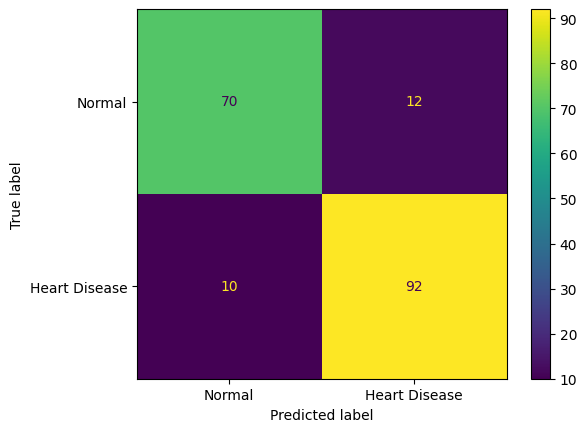

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
cr = classification_report(y_test, y_pred, target_names=["Normal", "Heart Disease"])
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print("Classification Report:")
print(cr)
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1-Score: {f1}")

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Heart Disease"])
display.plot()
plt.show()


Classification Report:
               precision    recall  f1-score   support

       Normal       0.93      0.63      0.75        82
Heart Disease       0.77      0.96      0.85       102

     accuracy                           0.82       184
    macro avg       0.85      0.80      0.80       184
 weighted avg       0.84      0.82      0.81       184

Accuracy: 0.8152173913043478
Precision: 0.8382424301242236
Recall: 0.8152173913043478
F1-Score: 0.8082545683679898


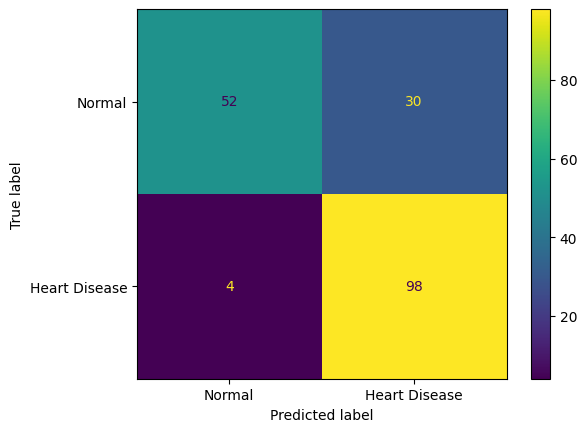

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

C = 0.01 # Regularization strength
threshold = 0.3 # Adjust the threshold for classifying as heart disease

model = LogisticRegression(C=C, random_state=42, max_iter=1000)
model.fit(x_train, y_train)
y_pred = (model.predict_proba(x_test)[:, 1] >= threshold).astype(int)
cr = classification_report(y_test, y_pred, target_names=["Normal", "Heart Disease"])
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print("Classification Report:")
print(cr)
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1-Score: {f1}")

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Heart Disease"])
display.plot()
plt.show()
